In [1]:
# IMPORTS
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix, lil_matrix
from pyproj import Transformer
from sklearn.preprocessing import StandardScaler
import pyreadr 
from pathlib import Path
import os

os.chdir(Path.cwd().parent)

In [ ]:
# ================================================================
# WEEKLY BYM + FACTOR (Double PolyGamma version)
# Two largest components
# ================================================================

import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm import tqdm
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import coo_matrix, csr_matrix, diags, bmat, block_diag
from scipy.sparse.csgraph import connected_components
from sksparse.cholmod import cholesky
from polyagamma import random_polyagamma
import pyreadr
import pickle

# ================================================================
# 1️⃣ Load data & remove isolated points
# ================================================================

no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

snow = pyreadr.read_r("snow_cleaned_full.Rda")
snow = list(snow.values())[0].reset_index(drop=True)
snow = snow.drop(index=no_nbs).reset_index(drop=True)

coords_full = snow.iloc[:, :2].to_numpy()
y_full = snow.iloc[:, 2:].to_numpy()

S0, TT = y_full.shape
period = 52

print("Initial S0 =", S0)

# ================================================================
# 2️⃣ Keep TWO largest connected components
# ================================================================

gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords_full[:,0], coords_full[:,1]),
    crs="EPSG:4326"
).to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")

xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6

W_full = (squareform(pdist(xy)) <= 0.22).astype(int)
np.fill_diagonal(W_full, 0)
W_full = csr_matrix(W_full)

n_comp, labels = connected_components(W_full, directed=False)
sizes = np.bincount(labels)
order = np.argsort(sizes)[::-1]

keep = np.sort(np.concatenate([
    np.where(labels == order[0])[0],
    np.where(labels == order[1])[0]
]))

coords = coords_full[keep]
y = y_full[keep]
W = W_full[keep][:, keep]

S, TT = y.shape
print("Using S =", S)

# ================================================================
# 3️⃣ CAR precision
# ================================================================

deg = np.array(W.sum(axis=1)).flatten()
Q_car = diags(deg) - W
I_S = diags(np.ones(S))

# ================================================================
# 4️⃣ Global trend
# ================================================================

t_full = np.arange(1, TT+1)
t_scaled_full = (t_full - t_full.mean()) / t_full.std()

# ================================================================
# 5️⃣ Build p01 dataset
# ================================================================

loc_mask = (y[:, :-1] == 0)
row_idx, time_idx = np.where(loc_mask)
N = len(row_idx)

next_y = y[row_idx, time_idx+1]
kappa = next_y - 0.5

t_raw = time_idx + 1
t_scaled = t_scaled_full[time_idx]
week_idx = (t_raw - 1) % 52

# ================================================================
# 6️⃣ Covariates (4 base)
# ================================================================

cov4 = np.column_stack([
    np.ones(N),
    np.cos(2*np.pi*(t_raw)/period),
    np.sin(2*np.pi*(t_raw)/period),
    t_scaled
])

K_base = 4
R = 2
K_total = K_base * R  # 8

# ================================================================
# 7️⃣ Factor covariates
# ================================================================

lat_raw = coords[:,1]
lat = (lat_raw - lat_raw.mean()) / lat_raw.std()

elev_raw = pd.read_csv("curr_elev.csv").iloc[:,3].to_numpy()
elev = (elev_raw[keep] - elev_raw[keep].mean()) / elev_raw[keep].std()

snow_temp = pyreadr.read_r("snow_temp_full.Rda")
snow_temp = list(snow_temp.values())[0].reset_index(drop=True)
temp_full = snow_temp.drop(index=no_nbs).iloc[:,2:].to_numpy()
temp_full = temp_full[keep]
temp_scaled = (temp_full - temp_full.mean()) / temp_full.std()

t_lat  = t_scaled * lat[row_idx]
t_elev = t_scaled * elev[row_idx]
t_temp = t_scaled * temp_scaled[row_idx, time_idx]

# ================================================================
# 8️⃣ Build X_eta_base (N × (8S+3))
# ================================================================

eta_dim = K_total*S + 3
rows_e, cols_e, vals_e = [], [], []

for i in range(N):

    s = row_idx[i]

    for k in range(K_base):

        xval = cov4[i,k]

        col_icar = (2*k)*S + s
        col_iid  = (2*k+1)*S + s

        rows_e += [i,i]
        cols_e += [col_icar, col_iid]
        vals_e += [xval, xval]

    # factor columns
    rows_e += [i,i,i]
    cols_e += [K_total*S, K_total*S+1, K_total*S+2]
    vals_e += [t_lat[i], t_elev[i], t_temp[i]]

X_eta_base = coo_matrix(
    (vals_e,(rows_e,cols_e)),
    shape=(N,eta_dim)
).tocsr()

# ================================================================
# 9️⃣ Build X_tau_base (N × 8*52)
# ================================================================

tau_dim = K_total * 52
rows_t, cols_t, vals_t = [], [], []

for i in range(N):

    w = week_idx[i]

    for k in range(K_base):

        xval = cov4[i,k]

        col_icar = (2*k)*52 + w
        col_iid  = (2*k+1)*52 + w

        rows_t += [i,i]
        cols_t += [col_icar, col_iid]
        vals_t += [xval, xval]

X_tau_base = coo_matrix(
    (vals_t,(rows_t,cols_t)),
    shape=(N,tau_dim)
).tocsr()

# ================================================================
# 🔟 Priors
# ================================================================

Q_blocks = []
for k in range(K_base):
    Q_blocks.append(Q_car)
    Q_blocks.append(I_S)

Q_spatial = bmat(
    [[Q_blocks[i] if i==j else None
      for j in range(K_total)]
     for i in range(K_total)],
    format="csr"
)

Q_factor = diags(np.ones(3)/9)
Q_eta = block_diag((Q_spatial, Q_factor), format="csr")

tau_prior_prec = diags(np.ones(tau_dim)/9)

# ================================================================
# 1️⃣1️⃣ MCMC
# ================================================================

burn, thin, tot_save = 5000, 5, 5000
total_iters = burn + thin*tot_save

curr_eta = np.zeros(eta_dim)
curr_tau = np.ones(tau_dim)

all_eta = np.zeros((eta_dim, tot_save))
all_tau = np.zeros((tau_dim, tot_save))

save_idx = 0

for it in tqdm(range(total_iters), desc="MCMC p01"):

    # ---- build X_tilde_eta (tau absorbed only on spatial part)
    X_tilde_eta = X_eta_base.copy()

    rows, cols = X_tilde_eta.nonzero()
    sp_mask = cols < K_total * S

    rows_sp = rows[sp_mask]
    cols_sp = cols[sp_mask]

    j = cols_sp // S
    w = week_idx[rows_sp]

    tau_indices = j * 52 + w
    X_tilde_eta.data[sp_mask] *= curr_tau[tau_indices]

    psi = X_tilde_eta @ curr_eta

    # ---- PG
    omega = random_polyagamma(1, psi)

    # ---- eta update
    XtOmega = X_tilde_eta.T.multiply(omega)
    post_prec_eta = XtOmega @ X_tilde_eta + Q_eta
    post_prec_eta = (post_prec_eta + post_prec_eta.T)*0.5
    post_prec_eta = post_prec_eta.tocsc()

    rhs_eta = X_tilde_eta.T @ kappa

    factor = cholesky(post_prec_eta, mode="simplicial")
    mu = factor.solve_A(rhs_eta)

    z = np.random.randn(eta_dim)
    z = z / np.sqrt(factor.D())
    z = factor.solve_Lt(z)
    z = factor.apply_Pt(z)

    curr_eta = mu + z

    # ============================================================
    # 4️⃣ Update tau 
    # ============================================================

    X_tilde_tau = X_tau_base.copy()

    rows_nz, cols_nz = X_tilde_tau.nonzero()

    # component index (0..7)
    j = cols_nz // 52

    # spatial location index
    s = row_idx[rows_nz]

    # eta indices for spatial part
    eta_indices = j * S + s

    # absorb eta into tau design
    X_tilde_tau.data *= curr_eta[eta_indices]

    gamma = curr_eta[K_total*S : K_total*S + 3]
    X_factor = X_eta_base[:, K_total*S : K_total*S + 3]

    c = X_factor @ gamma 
    residual = kappa - omega * c

    XtOmega = X_tilde_tau.T.multiply(omega)
    post_prec_tau = XtOmega @ X_tilde_tau + tau_prior_prec
    post_prec_tau = (post_prec_tau + post_prec_tau.T) * 0.5
    post_prec_tau = post_prec_tau.tocsc()

    rhs_tau = X_tilde_tau.T @ residual

    factor = cholesky(post_prec_tau, mode="simplicial")
    mu = factor.solve_A(rhs_tau)

    z = np.random.randn(tau_dim)
    z = z / np.sqrt(factor.D())
    z = factor.solve_Lt(z)
    z = factor.apply_Pt(z)

    curr_tau = mu + z

    if it >= burn and (it-burn)%thin==0:
        all_eta[:,save_idx] = curr_eta
        all_tau[:,save_idx] = curr_tau
        save_idx += 1
        if save_idx==tot_save:
            break

# ================================================================
# Save
# ================================================================

save_dict = {
    "all_eta": all_eta,
    "all_tau": all_tau,
    "S": S,
    "TT": TT,
    "transition": "p01"
}
BASE_DIR = r"D:\77\Research\temp\snow"
with open(BASE_DIR/"bym01_cov_weekly_tau9.pkl","wb") as f:
    pickle.dump(save_dict,f)

print("Saved bym01_cov_weekly.pkl")

In [ ]:
# ================================================================
# WEEKLY BYM + FACTOR (Double PolyGamma)
# p10 version
# ================================================================

import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm import tqdm
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import coo_matrix, csr_matrix, diags, bmat, block_diag
from scipy.sparse.csgraph import connected_components
from sksparse.cholmod import cholesky
from polyagamma import random_polyagamma
import pyreadr
import pickle

# ================================================================
# 1️⃣ Load data & remove isolated points
# ================================================================

no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

snow = pyreadr.read_r("snow_cleaned_full.Rda")
snow = list(snow.values())[0].reset_index(drop=True)
snow = snow.drop(index=no_nbs).reset_index(drop=True)

coords_full = snow.iloc[:, :2].to_numpy()
y_full = snow.iloc[:, 2:].to_numpy()

period = 52

# ================================================================
# 2️⃣ Keep TWO largest connected components
# ================================================================

gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords_full[:,0], coords_full[:,1]),
    crs="EPSG:4326"
).to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")

xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6

W_full = (squareform(pdist(xy)) <= 0.22).astype(int)
np.fill_diagonal(W_full, 0)
W_full = csr_matrix(W_full)

n_comp, labels = connected_components(W_full, directed=False)
sizes = np.bincount(labels)
order = np.argsort(sizes)[::-1]

keep = np.sort(np.concatenate([
    np.where(labels == order[0])[0],
    np.where(labels == order[1])[0]
]))

coords = coords_full[keep]
y = y_full[keep]
W = W_full[keep][:, keep]

S, TT = y.shape
print("Using S =", S)

# ================================================================
# 3️⃣ CAR precision
# ================================================================

deg = np.array(W.sum(axis=1)).flatten()
Q_car = diags(deg) - W
I_S = diags(np.ones(S))

# ================================================================
# 4️⃣ Global trend
# ================================================================

t_full = np.arange(1, TT+1)
t_scaled_full = (t_full - t_full.mean()) / t_full.std()

# ================================================================
# 5️⃣ Build p10 dataset
# ================================================================

loc_mask = (y[:, :-1] == 1)
row_idx, time_idx = np.where(loc_mask)
N = len(row_idx)

next_y = y[row_idx, time_idx+1]

# success = next state = 0
kappa = (1 - next_y) - 0.5

t_raw = time_idx + 1
t_scaled = t_scaled_full[time_idx]
week_idx = (t_raw - 1) % 52

# ================================================================
# 6️⃣ Covariates
# ================================================================

cov4 = np.column_stack([
    np.ones(N),
    np.cos(2*np.pi*t_raw/period),
    np.sin(2*np.pi*t_raw/period),
    t_scaled
])

K_base = 4
K_total = 8

# ================================================================
# 7️⃣ Factor covariates
# ================================================================

lat_raw = coords[:,1]
lat = (lat_raw - lat_raw.mean()) / lat_raw.std()

elev_raw = pd.read_csv("curr_elev.csv").iloc[:,3].to_numpy()
elev = (elev_raw[keep] - elev_raw[keep].mean()) / elev_raw[keep].std()

snow_temp = pyreadr.read_r("snow_temp_full.Rda")
snow_temp = list(snow_temp.values())[0].reset_index(drop=True)
temp_full = snow_temp.drop(index=no_nbs).iloc[:,2:].to_numpy()
temp_full = temp_full[keep]
temp_scaled = (temp_full - temp_full.mean()) / temp_full.std()

t_lat  = t_scaled * lat[row_idx]
t_elev = t_scaled * elev[row_idx]
t_temp = t_scaled * temp_scaled[row_idx, time_idx]

# ================================================================
# 8️⃣ Build X_eta_base
# ================================================================

eta_dim = K_total*S + 3
rows_e, cols_e, vals_e = [], [], []

for i in range(N):
    s = row_idx[i]

    for k in range(K_base):
        xval = cov4[i,k]

        rows_e += [i,i]
        cols_e += [(2*k)*S + s, (2*k+1)*S + s]
        vals_e += [xval, xval]

    rows_e += [i,i,i]
    cols_e += [K_total*S, K_total*S+1, K_total*S+2]
    vals_e += [t_lat[i], t_elev[i], t_temp[i]]

X_eta_base = coo_matrix(
    (vals_e,(rows_e,cols_e)),
    shape=(N,eta_dim)
).tocsr()

# ================================================================
# 9️⃣ Build X_tau_base
# ================================================================

tau_dim = K_total * 52
rows_t, cols_t, vals_t = [], [], []

for i in range(N):
    w = week_idx[i]

    for k in range(K_base):
        xval = cov4[i,k]
        rows_t += [i,i]
        cols_t += [(2*k)*52 + w, (2*k+1)*52 + w]
        vals_t += [xval, xval]

X_tau_base = coo_matrix(
    (vals_t,(rows_t,cols_t)),
    shape=(N,tau_dim)
).tocsr()

# ================================================================
# 🔟 Priors
# ================================================================

Q_blocks = []
for k in range(K_base):
    Q_blocks.append(Q_car)
    Q_blocks.append(I_S)

Q_spatial = bmat(
    [[Q_blocks[i] if i==j else None
      for j in range(K_total)]
     for i in range(K_total)],
    format="csr"
)

Q_factor = diags(np.ones(3))
Q_eta = block_diag((Q_spatial, Q_factor), format="csr")

tau_prior_prec = diags(np.ones(tau_dim)/9)

# ================================================================
# 1️⃣1️⃣ MCMC
# ================================================================

burn, thin, tot_save = 5000, 5, 5000
total_iters = burn + thin*tot_save

curr_eta = np.zeros(eta_dim)
curr_tau = np.ones(tau_dim)

all_eta = np.zeros((eta_dim, tot_save))
all_tau = np.zeros((tau_dim, tot_save))

save_idx = 0

for it in tqdm(range(total_iters), desc="MCMC p10"):

    # ---- absorb tau into spatial part
    X_tilde_eta = X_eta_base.copy()

    rows, cols = X_tilde_eta.nonzero()
    sp_mask = cols < K_total * S

    rows_sp = rows[sp_mask]
    cols_sp = cols[sp_mask]

    j = cols_sp // S
    w = week_idx[rows_sp]
    tau_indices = j * 52 + w

    X_tilde_eta.data[sp_mask] *= curr_tau[tau_indices]

    psi = X_tilde_eta @ curr_eta
    omega = random_polyagamma(1, psi)

    # ---- eta update
    XtOmega = X_tilde_eta.T.multiply(omega)
    post_prec_eta = XtOmega @ X_tilde_eta + Q_eta
    post_prec_eta = (post_prec_eta + post_prec_eta.T)*0.5
    post_prec_eta = post_prec_eta.tocsc()

    rhs_eta = X_tilde_eta.T @ kappa

    factor = cholesky(post_prec_eta, mode="simplicial")
    mu = factor.solve_A(rhs_eta)

    z = np.random.randn(eta_dim)
    z = z / np.sqrt(factor.D())
    z = factor.solve_Lt(z)
    z = factor.apply_Pt(z)

    curr_eta = mu + z

    # ---- tau update
    X_tilde_tau = X_tau_base.copy()
    rows_nz, cols_nz = X_tilde_tau.nonzero()

    j = cols_nz // 52
    s = row_idx[rows_nz]
    eta_indices = j * S + s

    X_tilde_tau.data *= curr_eta[eta_indices]

    gamma = curr_eta[K_total*S : K_total*S + 3]
    X_factor = X_eta_base[:, K_total*S : K_total*S + 3]
    c = X_factor @ gamma
    residual = kappa - omega * c

    XtOmega = X_tilde_tau.T.multiply(omega)
    post_prec_tau = XtOmega @ X_tilde_tau + tau_prior_prec
    post_prec_tau = (post_prec_tau + post_prec_tau.T)*0.5
    post_prec_tau = post_prec_tau.tocsc()

    rhs_tau = X_tilde_tau.T @ residual

    factor = cholesky(post_prec_tau, mode="simplicial")
    mu = factor.solve_A(rhs_tau)

    z = np.random.randn(tau_dim)
    z = z / np.sqrt(factor.D())
    z = factor.solve_Lt(z)
    z = factor.apply_Pt(z)

    curr_tau = mu + z

    if it >= burn and (it-burn)%thin==0:
        all_eta[:,save_idx] = curr_eta
        all_tau[:,save_idx] = curr_tau
        save_idx += 1
        if save_idx==tot_save:
            break

# ================================================================
# Save
# ================================================================

save_dict = {
    "all_eta": all_eta,
    "all_tau": all_tau,
    "S": S,
    "TT": TT,
    "transition": "p10"
}

with open(BASE_DIR+r"bym10_cov_weekly_tau9.pkl","wb") as f:
    pickle.dump(save_dict,f)

print("Saved bym10_cov_weekly.pkl")

Using S = 1557


MCMC p10:   0%|          | 11/30000 [00:29<22:25:36,  2.69s/it]

In [5]:
# ================================================================
# Posterior Mean Log-Likelihood
# Weekly BYM + Factor (Double PolyGamma)
# ================================================================

import numpy as np
import pickle
import pyreadr
import geopandas as gpd
from tqdm import tqdm
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import coo_matrix, csr_matrix
from scipy.sparse.csgraph import connected_components

DIST_TH = 0.22
period = 52
BASE_DIR = Path(r"D:\77\Research\temp\snow")
no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

# ================================================================
# 1️⃣ Load data
# ================================================================

snow = pyreadr.read_r("snow_cleaned_full.Rda")
snow = list(snow.values())[0].reset_index(drop=True)
snow = snow.drop(index=no_nbs).reset_index(drop=True)

coords_full = snow.iloc[:, :2].to_numpy()
y_full = snow.iloc[:, 2:].to_numpy()

# ================================================================
# 2️⃣ Keep two largest components
# ================================================================

gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords_full[:,0], coords_full[:,1]),
    crs="EPSG:4326"
).to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")

xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6
W = (squareform(pdist(xy)) <= DIST_TH).astype(int)
np.fill_diagonal(W, 0)
W = csr_matrix(W)

n_comp, labels = connected_components(W, directed=False)
sizes = np.bincount(labels)
order = np.argsort(sizes)[::-1]

keep = np.sort(np.concatenate([
    np.where(labels == order[0])[0],
    np.where(labels == order[1])[0]
]))

coords = coords_full[keep]
y = y_full[keep]

S, TT = y.shape

# ================================================================
# 3️⃣ Global trend + covariates
# ================================================================

t_full = np.arange(1, TT+1)
t_scaled_full = (t_full - t_full.mean()) / t_full.std()

snow_temp = pyreadr.read_r(BASE_DIR/"snow_temp_full.Rda")
snow_temp = list(snow_temp.values())[0].reset_index(drop=True)
temp_full = snow_temp.drop(index=no_nbs).iloc[:,2:].to_numpy()
temp_full = temp_full[keep]
temp_scaled = (temp_full - temp_full.mean()) / temp_full.std()

lat = coords[:,1]
lat = (lat - lat.mean()) / lat.std()

import pandas as pd
elev_raw = pd.read_csv("curr_elev.csv").iloc[:,3].to_numpy()
elev = (elev_raw[keep] - elev_raw[keep].mean()) / elev_raw[keep].std()


# ================================================================
# 4️⃣ Build design (same as fitting)
# ================================================================

def build_design(transition):

    if transition == "p01":
        loc_mask = (y[:, :-1] == 0)
        success = lambda ny: ny
    else:
        loc_mask = (y[:, :-1] == 1)
        success = lambda ny: 1 - ny

    row_idx, time_idx = np.where(loc_mask)
    pairs = np.column_stack([row_idx, time_idx])
    pairs = pairs[np.lexsort((pairs[:,0], pairs[:,1]))]
    pairs[:,1] += 1

    row_idx = pairs[:,0]
    time_idx = pairs[:,1] - 1

    next_y = y[pairs[:,0], pairs[:,1]]
    y_vec = success(next_y).astype(float)

    t_raw = time_idx + 1
    t_scaled = t_scaled_full[time_idx]
    week_idx = (t_raw - 1) % 52

    cov4 = np.column_stack([
        np.ones(len(row_idx)),
        np.cos(2*np.pi*t_raw/period),
        np.sin(2*np.pi*t_raw/period),
        t_scaled
    ])

    K_base = 4
    K_total = 8
    eta_dim = K_total*S + 3
    tau_dim = K_total * 52

    rows_e, cols_e, vals_e = [], [], []
    rows_t, cols_t, vals_t = [], [], []

    for i in range(len(row_idx)):
        s = row_idx[i]
        w = week_idx[i]

        for k in range(K_base):
            xval = cov4[i,k]

            # eta spatial
            rows_e += [i,i]
            cols_e += [(2*k)*S + s, (2*k+1)*S + s]
            vals_e += [xval, xval]

            # tau weekly
            rows_t += [i,i]
            cols_t += [(2*k)*52 + w, (2*k+1)*52 + w]
            vals_t += [xval, xval]

        # factor
        rows_e += [i,i,i]
        cols_e += [K_total*S, K_total*S+1, K_total*S+2]
        vals_e += [
            t_scaled[i]*lat[s],
            t_scaled[i]*elev[s],
            temp_scaled[s,time_idx[i]]
        ]

    X_eta = coo_matrix((vals_e,(rows_e,cols_e)),
                       shape=(len(row_idx),eta_dim)).tocsr()

    X_tau = coo_matrix((vals_t,(rows_t,cols_t)),
                       shape=(len(row_idx),tau_dim)).tocsr()

    return X_eta, X_tau, y_vec, week_idx, row_idx


# ================================================================
# 5️⃣ LLH computation
# ================================================================

def compute_llh(pkl_file, transition):

    with open(pkl_file,"rb") as f:
        res = pickle.load(f)

    all_eta = res["all_eta"]
    all_tau = res["all_tau"]

    X_eta, X_tau, y_vec, week_idx, row_idx = build_design(transition)

    K_total = 8
    eta_dim = all_eta.shape[0]
    M = all_eta.shape[1]

    llh_draws = np.zeros(M)

    for m in tqdm(range(M), desc=f"LLH {transition}"):

        eta = all_eta[:,m]
        tau = all_tau[:,m]

        # absorb tau into spatial part
        X_tilde = X_eta.copy()
        rows, cols = X_tilde.nonzero()
        sp_mask = cols < K_total*S

        rows_sp = rows[sp_mask]
        cols_sp = cols[sp_mask]

        j = cols_sp // S
        w = week_idx[rows_sp]

        tau_idx = j*52 + w
        X_tilde.data[sp_mask] *= tau[tau_idx]

        psi = X_tilde @ eta

        # stable logistic loglik
        softplus = np.log1p(np.exp(-np.abs(psi))) + np.maximum(psi,0)
        llh_draws[m] = np.sum(y_vec * psi - softplus)

    return llh_draws.mean()


# ================================================================
# 6️⃣ Run
# ================================================================

llh01 = compute_llh(BASE_DIR/"bym01_cov_weekly.pkl","p01")
llh10 = compute_llh(BASE_DIR/"bym10_cov_weekly.pkl","p10")

print("\nPosterior mean LLH p01:", llh01)
print("Posterior mean LLH p10:", llh10)
print("TOTAL LLH:", llh01 + llh10)

LLH p10: 100%|██████████| 1000/1000 [06:40<00:00,  2.50it/s]


Posterior mean LLH p01: -334916.33479706064
Posterior mean LLH p10: -263170.8735202704
TOTAL LLH: -598087.208317331


In [7]:
# ================================================================
# LLH of Posterior Mean
# ================================================================

def compute_llh_postmean(pkl_file, transition):

    with open(pkl_file,"rb") as f:
        res = pickle.load(f)

    all_eta = res["all_eta"]
    all_tau = res["all_tau"]

    # posterior mean
    eta_mean = all_eta.mean(axis=1)
    tau_mean = all_tau.mean(axis=1)

    X_eta, X_tau, y_vec, week_idx, row_idx = build_design(transition)

    K_total = 8
    eta_dim = eta_mean.shape[0]

    # absorb tau into spatial part
    X_tilde = X_eta.copy()
    rows, cols = X_tilde.nonzero()
    sp_mask = cols < K_total*S

    rows_sp = rows[sp_mask]
    cols_sp = cols[sp_mask]

    j = cols_sp // S
    w = week_idx[rows_sp]

    tau_idx = j*52 + w
    X_tilde.data[sp_mask] *= tau_mean[tau_idx]

    psi = X_tilde @ eta_mean

    # stable logistic loglik
    softplus = np.log1p(np.exp(-np.abs(psi))) + np.maximum(psi,0)
    llh = np.sum(y_vec * psi - softplus)

    return llh

llh01_pm = compute_llh_postmean(
    BASE_DIR/"bym01_cov_weekly.pkl","p01"
)

llh10_pm = compute_llh_postmean(
    BASE_DIR/"bym10_cov_weekly.pkl","p10"
)

print("\nPosterior mean LLH (theta_mean) p01:", llh01_pm)
print("Posterior mean LLH (theta_mean) p10:", llh10_pm)
print("TOTAL LLH (post mean):", llh01_pm + llh10_pm)


Posterior mean LLH (theta_mean) p01: -331963.8596693633
Posterior mean LLH (theta_mean) p10: -261439.4260075791
TOTAL LLH (post mean): -593403.2856769424


In [9]:
2*(-598087.208317331*2 + 593403.2856769424)

-1205542.2619154393

In [10]:
# Compare with no covariates posterior mean of llh : -592509.5837407765
# Compare with no covariates llh at posterior mean : -588641.3075797923
# DIC
2*(-592509.5837407765 * 2 + 588641.3075797923)

-1192755.7198035214

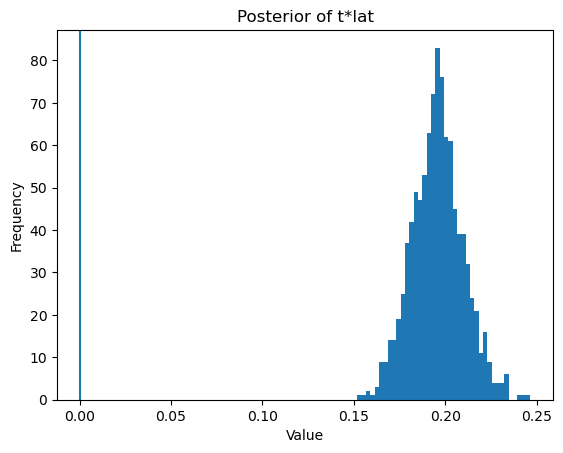

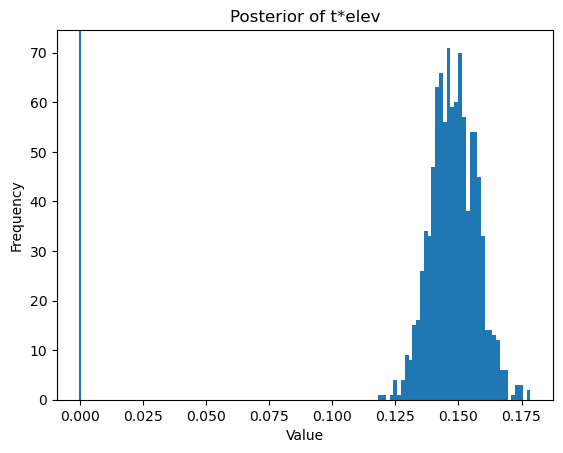

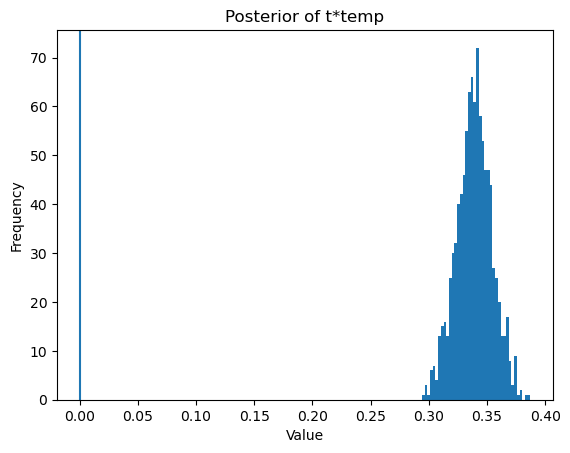

In [19]:
import matplotlib.pyplot as plt

gamma_samples = all_eta[K_total*S : K_total*S+3, :]

names = ["t*lat", "t*elev", "t*temp"]

for i in range(3):
    plt.figure()
    plt.hist(gamma_samples[i], bins=40)
    plt.axvline(0)
    plt.title(f"Posterior of {names[i]}")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.show()

In [15]:
all_eta.shape

(12459, 1000)